In [1]:
from collections import Counter, defaultdict
import anndata as ad
import scanpy as sc
import matplotlib.pyplot as plt
import pandas as pd

# 1. Gene-based analysis

AnnData object with n_obs × n_vars = 2535 × 27524
    obs: 'Run', 'Barcode', 'Species', 'CellType', 's4U', 'Time', 'ActD', 'Phase', 'IAA', 'Stage', 'Cell.Reads', 'Cell.Bases', 'Trimmed.Reads', 'Trimmed.Ratio', 'Mapped.Reads', 'Mapped.Ratio', 'Mito.Ratio', 'Filtered.Reads', 'Filtered.Ratio', 'FilteredClip.Reads', 'FilteredClip.Ratio', 'UMIs', 'mrUMIs', 'Duplicate.Reads', 'Duplicate.Ratio', 'Unique.Reads', 'Genes', 'Isoforms.Assembled', 'Isoforms.Known', 'AC.Ratio', 'AG.Ratio', 'AT.Ratio', 'CA.Ratio', 'CG.Ratio', 'CT.Ratio', 'GA.Ratio', 'GC.Ratio', 'GT.Ratio', 'TA.Ratio', 'TC.Ratio', 'TG.Ratio', 'Pe', 'Pc', 'SNR', 'mrUMIs.New', 'mrUMIs.New.Ratio', 'mrGenes', 'mrGenes.New'
    var: 'GeneID', 'GeneType', 'Chrom', 'Start', 'End', 'Strand'
    uns: 'log1p'
    layers: 'new', 'total', 'counts', 'scaled'


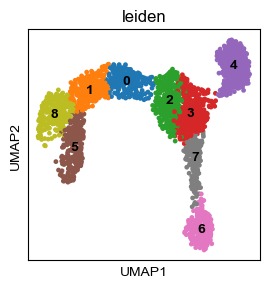

In [2]:
adata = ad.read_h5ad("results/h5ad_qc/Blastocyst.gene_based.annotated.h5ad")
adata.layers["counts"] = adata.X.copy()
sc.pp.normalize_total(adata)
adata.layers["scaled"] = sc.pp.scale(adata, copy=True).X
sc.pp.log1p(adata)
print(adata)

sc.pp.highly_variable_genes(adata, n_top_genes=1000)
sc.tl.pca(adata)
sc.pp.neighbors(adata)
sc.tl.umap(adata)
sc.tl.leiden(adata, flavor="igraph", n_iterations=2)
with plt.rc_context({"figure.figsize": (3, 3)}):
    sc.pl.umap(adata, color="leiden", legend_loc="on data")

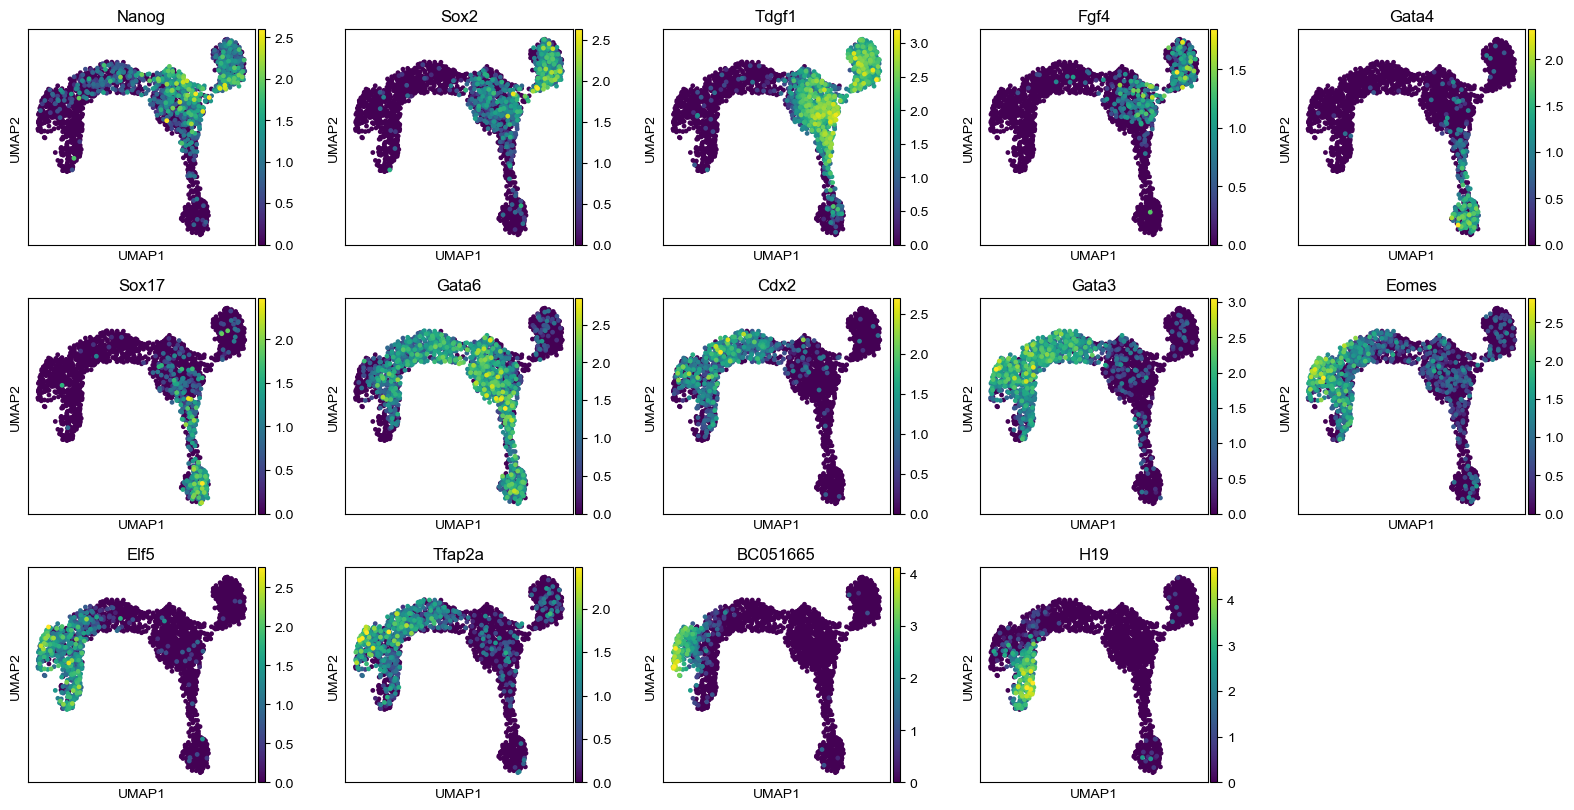

In [3]:
# Check markers

markers = [
    "Nanog", "Sox2", "Tdgf1", "Fgf4", # ICM, EPI
    "Gata4", "Sox17", "Gata6", # PE
    "Cdx2", "Gata3", "Eomes", "Elf5", "Tfap2a", # TE
    "BC051665", # muralTE
    "H19" # polarTE
]

with plt.rc_context({"figure.figsize": (3, 3)}):
    fig = sc.pl.umap(adata, color=markers, ncols=5)

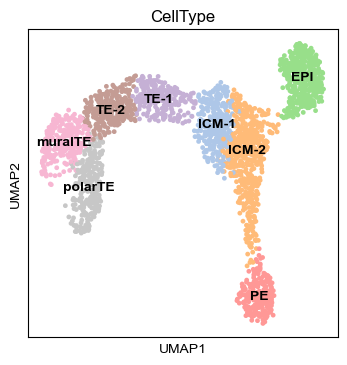

In [4]:
# Annotate cell-type

adata.obs["CellType"] = adata.obs["leiden"].map({
    "2": "ICM-1",
    "3": "ICM-2",
    "7": "ICM-2",
    "4": "EPI",
    "6": "PE",
    "0": "TE-1", 
    "1": "TE-2",
    "8": "muralTE",
    "5": "polarTE",
})
adata.obs["CellType"] = pd.Categorical(
    adata.obs["CellType"], 
    categories=["PE", "EPI", "ICM-2", "ICM-1", "TE-1", "TE-2", "muralTE", "polarTE"])


cmap = plt.colormaps["tab20"]
palette = {
    "ICM-1": cmap(1), 
    "ICM-2": cmap(3),
    "EPI": cmap(5),
    "PE": cmap(7),
    "TE-1": cmap(9),
    "TE-2": cmap(11),
    "muralTE": cmap(13),
    "polarTE": cmap(15)
}

with plt.rc_context({"figure.figsize": (4, 4)}):
    sc.pl.umap(adata, color="CellType", palette=palette, legend_loc="on data")

In [5]:
sc.tl.rank_genes_groups(adata, groupby="CellType", method="wilcoxon")
sc.tl.dendrogram(adata, groupby="CellType")

In [6]:
adata.write("results/h5ad_clustered/Blastocyst.gene_based.h5ad", compression="gzip")
adata.obs.to_csv("results/h5ad_clustered/Blastocyst.gene_based.obs.csv")

# 2. Transcript-based analysis

Before filtering: (2535, 70060)
After filtering: 2535


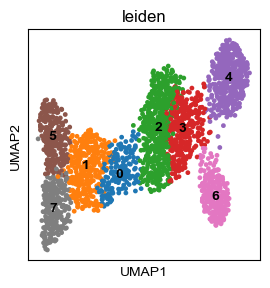

In [7]:
adata = ad.read_h5ad("results/h5ad_qc/Blastocyst.transcript_based.annotated.h5ad")
print("Before filtering:", adata.shape)
sc.pp.filter_genes(adata, min_cells=3)
adata.layers["counts"] = adata.X.copy()
sc.pp.normalize_total(adata)
adata.layers["scaled"] = sc.pp.scale(adata, copy=True).X
sc.pp.log1p(adata)
print("After filtering:", len(adata))

sc.pp.highly_variable_genes(adata, n_top_genes=1000)
sc.tl.pca(adata)
sc.pp.neighbors(adata)
sc.tl.umap(adata)
sc.tl.leiden(adata, flavor="igraph", n_iterations=2)
with plt.rc_context({"figure.figsize": (3, 3)}):
    sc.pl.umap(adata, color="leiden", legend_loc="on data")

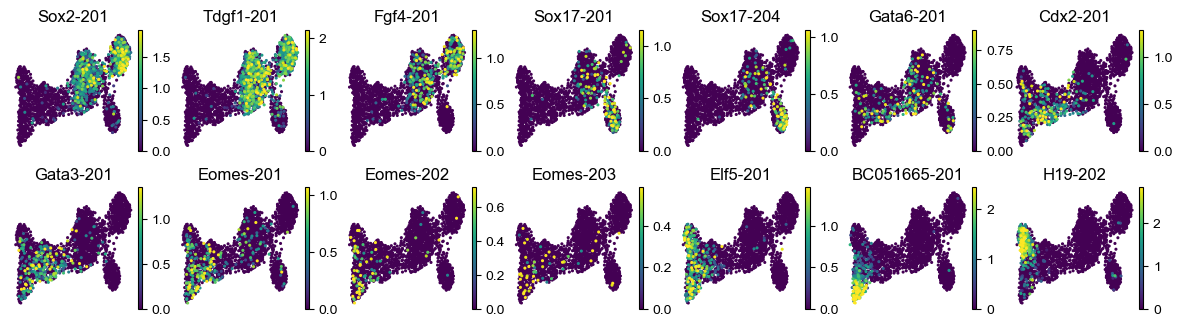

In [8]:
markers = [
    "Sox2-201", "Tdgf1-201", "Fgf4-201",
    "Sox17-201", "Sox17-204", "Gata6-201", 
    "Cdx2-201", "Gata3-201", "Eomes-201", "Eomes-202", "Eomes-203", "Elf5-201",
    "BC051665-201", "H19-202"
]
with plt.rc_context({"figure.figsize": (1.7, 1.7)}):
    fig = sc.pl.umap(adata, color=markers, s=20, frameon=False, ncols=7, vmax="p99", wspace=0.2, hspace=0.3)

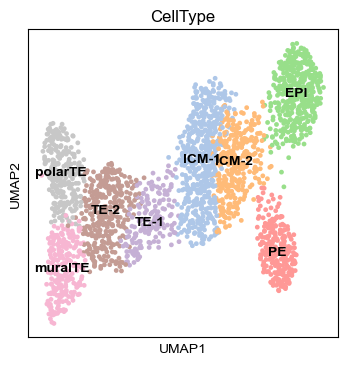

In [9]:
adata.obs["CellType"] = adata.obs["leiden"].map({
    "2": "ICM-1",
    "3": "ICM-2",
    "4": "EPI",
    "6": "PE",
    "0": "TE-1", 
    "1": "TE-2",
    "7": "muralTE",
    "5": "polarTE",
})
adata.obs["CellType"] = pd.Categorical(
    adata.obs["CellType"], 
    categories=["PE", "EPI", "ICM-2", "ICM-1", "TE-1", "TE-2", "muralTE", "polarTE"])

cmap = plt.colormaps["tab20"]
palette = {
    "ICM-1": cmap(1), 
    "ICM-2": cmap(3),
    "EPI": cmap(5),
    "PE": cmap(7),
    "TE-1": cmap(9),
    "TE-2": cmap(11),
    "muralTE": cmap(13),
    "polarTE": cmap(15)
}
with plt.rc_context({"figure.figsize": (4, 4)}):
    sc.pl.umap(adata, color="CellType", palette=palette, legend_loc="on data")

In [10]:
sc.tl.rank_genes_groups(adata, groupby="CellType", method="wilcoxon")
sc.tl.dendrogram(adata, groupby="CellType")

In [11]:
adata.write("results/h5ad_clustered/Blastocyst.transcript_based.h5ad", compression="gzip")
adata.obs.to_csv("results/h5ad_clustered/Blastocyst.transcript_based.obs.csv")